In [ ]:
from ihp import PDK
from ihp.cells.inductors import inductor3
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

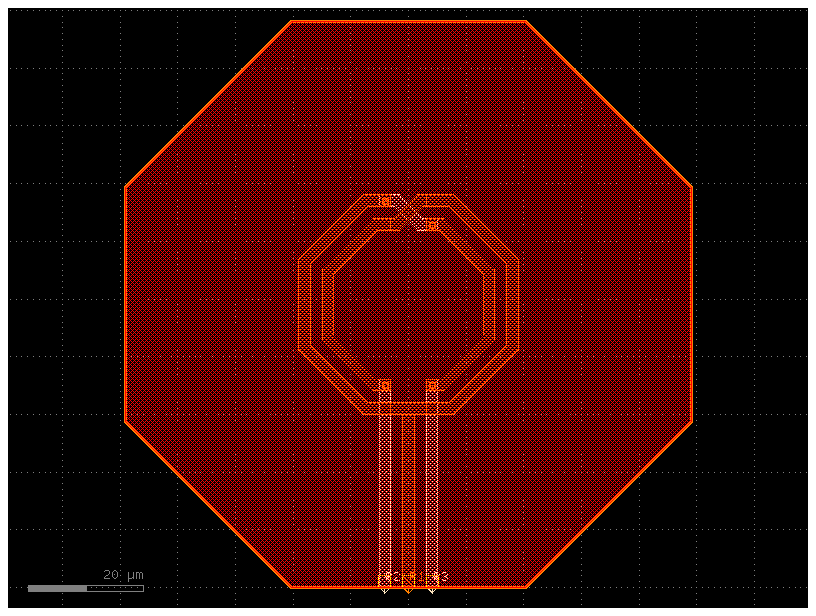

In [2]:
c = inductor3()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [3]:
cc.ports

["Port(self.name='P1', self.width=2000, trans=r270 *1 0,0, layer=TopMetal2pin (134/2), port_type=electrical)", "Port(self.name='P2', self.width=2000, trans=r270 *1 -4.1,0, layer=TopMetal1pin (126/2), port_type=electrical)", "Port(self.name='P3', self.width=2000, trans=r270 *1 4.1,0, layer=TopMetal1pin (126/2), port_type=electrical)"]

In [4]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-inductor3")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("P1",layer="topmetal2")
sim.add_port("P2",layer="topmetal1")
sim.add_port("P3",layer="topmetal1")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [5]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 238.0 x 268.0 x 518.3 µm
Nodes:      2,596
Elements:   20,409
Tetrahedra: 14,665
Edge length: 0.40 - 130.32 µm
Quality:    0.610 (min: 0.001)
SICN:       0.650 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (8):
  - topmetal1_xy [6]
  - topmetal1_z [7]
  - topmetal2_xy [8]
  - topmetal2_z [9]
  - P1 [10]
  - P2 [11]
  - P3 [12]
  - Absorbing_boundary [13]
----------------------------------------
Mesh:   ../palace-sim-inductor3/palace.msh

2026-03-10 09:42:34.726 (   1.375s) [    784C8BEDE080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:34.736 (   1.385s) [    784C8BEDE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:34.752 (   1.401s) [    784C8BEDE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:42:34.794 (   1.442s) [    784C8BEDE080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


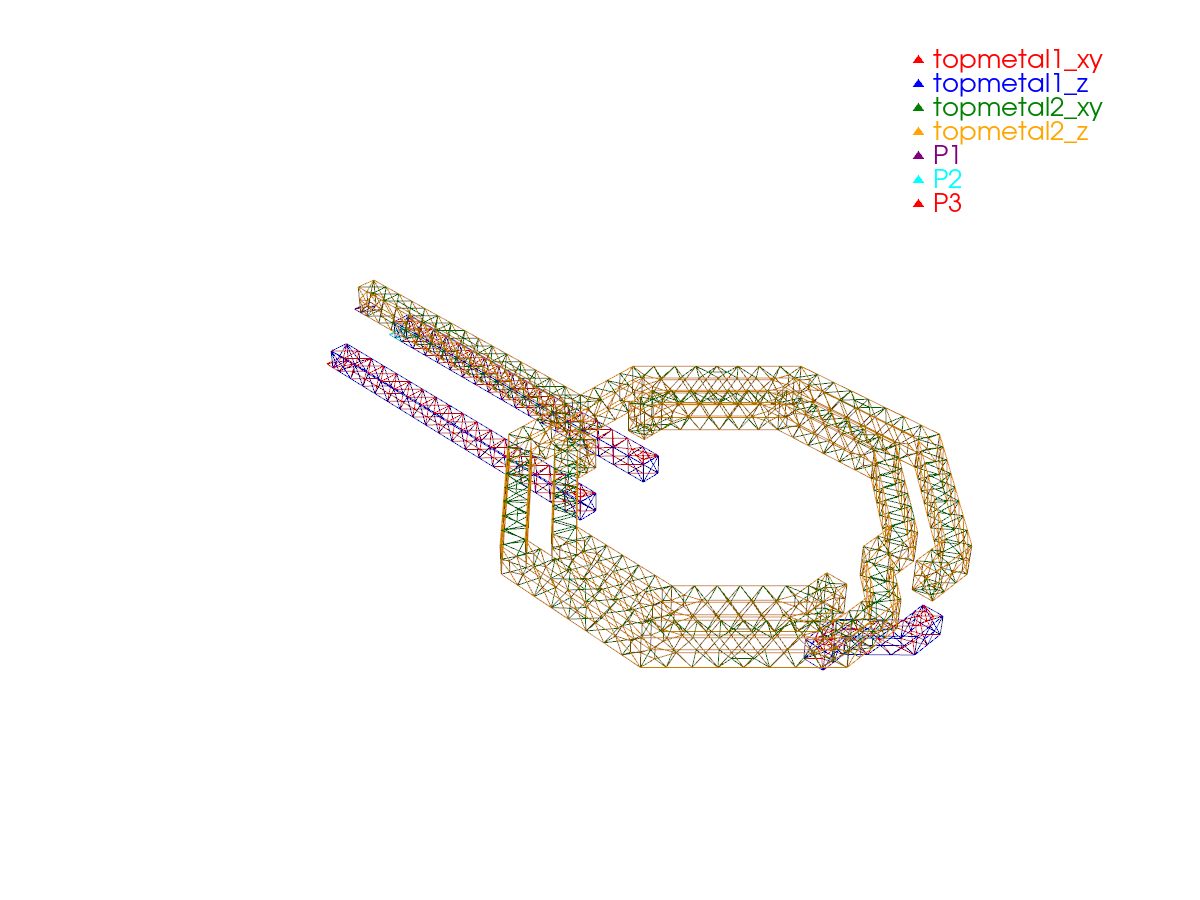

In [6]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)